In [20]:
using Pkg
Pkg.activate(".")

using LinearAlgebra, GenericLinearAlgebra, StaticArrays, SparseArrays, Random
using MultivariateStats
using StatsBase
using Base.Threads
using CUDA, Adapt, KernelAbstractions, GPUArrays
using Plots, StatsPlots, JLD2
using Clustering, Graphs
using DictionaryLearning
using FLoops
using IterativeSolvers
using KrylovKit, Krylov
using DoubleFloats
using NNlib

include("../debug.jl")

savepath = "../../temp/ssdl"

# plot theme
theme(:rose_pine)

# choose backend
back = CUDA.functional() ? CUDABackend() : CPU()

# set threads
BLAS.set_num_threads(nthreads())

println("$INF backend: $back")
println("$INF # threads: $(nthreads())")
;

  Activating 

[INF] backend: CUDABackend(false, false)
[INF] # threads: 32


project at `~/DictionaryLearning/examples/dictionary-learning`


In [ ]:
@load "../../temp/fl-example/fls.jld2" fls
D_cpu = adapt(CPU(), fls.G)
normalize!.(eachcol(D_cpu))

m, k = size(D_cpu)

# small example
s = 4
n = 10000
t = 3000

println("$INF m = $m")
println("$INF k = $k")
println("$INF n = $n")
println("$INF t = $t")
println("$INF s = $s")
println("$INF sizeof(Y) = $(m*n*sizeof(eltype(D))*1e-9)GB")
;

[INF] m = 255
[INF] k = 169
[INF] n = 10000
[INF] t = 3000
[INF] s = 4
[INF] sizeof(Y) = 0.0408GB


In [22]:
D = adapt(back, D_cpu)
X_cpu = gen_sparse_samples(eltype(D), k, n, s)
X = adapt(back, X_cpu)
;

In [23]:
W, Winv = get_white(D*X, k, s)
D_white = W * D
;

[INF] maximum coherence before whitening: 0.8453363050051927
[INF] maximum coherence after whitening: 0.030970378012860806


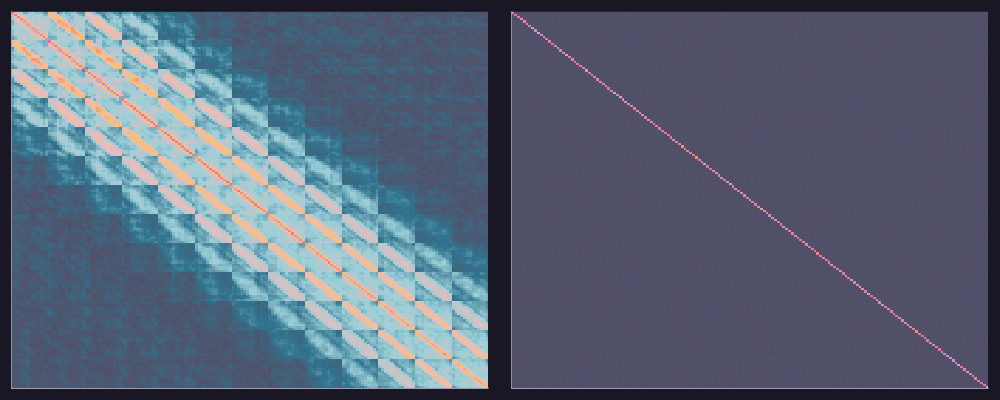

In [24]:
println("$INF maximum coherence before whitening: $(max_offdiag_coh(D))")
println("$INF maximum coherence after whitening: $(max_offdiag_coh(D_white))")

# force GPU cleanup
if back == CUDABackend()
    GC.gc()
    CUDA.reclaim()
end

p1 = heatmap(adapt(CPU(), abs.(D'*D)), yflip=true, legend=false, xticks=false, yticks=false)
savefig("$savepath/coh.pdf")

p2 = heatmap(adapt(CPU(), abs.(D_white'*D_white)), yflip=true, legend=false, xticks=false, yticks=false)
savefig("$savepath/coh-white.pdf")

plot(p1, p2, layout=(1,2), size=(1000, 400))

In [25]:
sfsrs = SSDLFakeSubRecStruct(D_white, X_cpu, s, t)
sfsrs_true = SSDLFakeSubRecStruct(D_white, X_cpu, s, t)
ssdl_subrec!(sfsrs)
ssdl_subrec_true!(sfsrs_true)

# force GPU cleanup
if back == CUDABackend()
    GC.gc()
    CUDA.reclaim()
end

;

mean SPA error: 0.08524318807964193
mean f-norm error: 0.10892597075423298


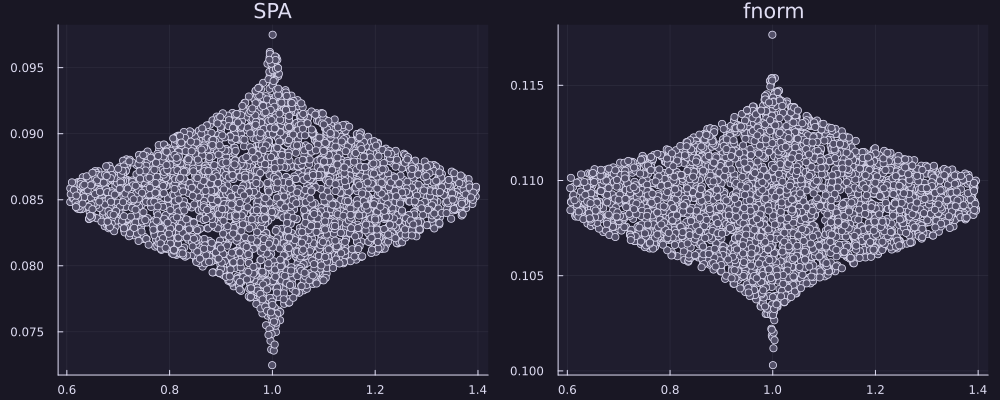

In [26]:
let
    errs = subdist.(
        eachslice(sfsrs.S, dims=3), 
        eachslice(sfsrs_true.S, dims=3),
        :spa
    )
    println("mean SPA error: $(mean(errs))")
    p1 = dotplot(errs, label=:none, title="SPA")

    errs = subdist.(
        eachslice(sfsrs.S, dims=3), 
        eachslice(sfsrs_true.S, dims=3),
        :fnorm
    ) ./ sqrt(s)
    println("mean f-norm error: $(mean(errs))")
    p2 = dotplot(errs, label=:none, title="fnorm")

    return plot(p1, p2, layout=(1, 2), size=(1000, 400))
end

In [27]:
ssds = SSDLSubDistStruct(sfsrs, :spa)
stsds = SSDLTrueSubDistStruct(sfsrs_true, :spa)

let
    sub_dist!(ssds)
    sub_dist!(stsds)
end

# force GPU cleanup
if back == CUDABackend()
    GC.gc()
    CUDA.reclaim()
end
;

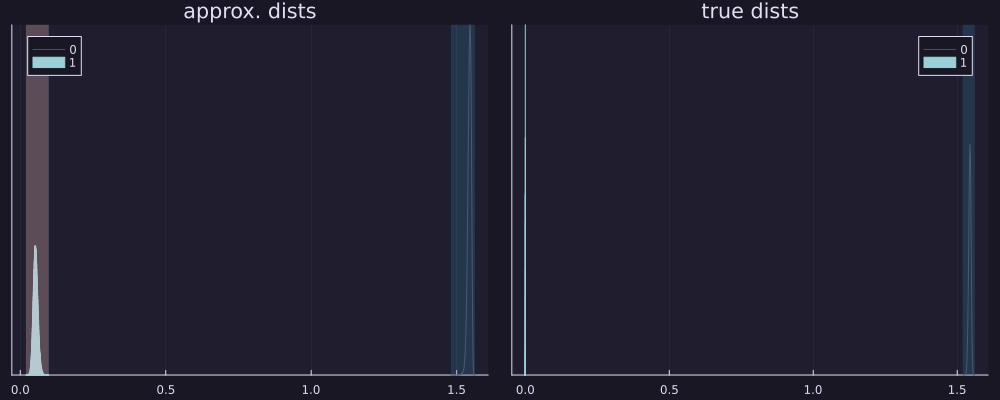

In [28]:
let 
    Cvec = vec(stsds.C)
    
    p1 = plot(title="approx. dists", yticks=:none)
    Dvec = copy(vec(adapt(CPU(), ssds.D)))
    for i in 0:1
        idxs = setdiff(findall(isequal(i), Cvec), 1:t+1:t^2)
        sds = Dvec[idxs]
        if length(sds) > 0
            histogram!(sds, linecolor = :match, label="$i")
        end
        vspan!([minimum(sds), maximum(sds)], alpha=0.3, label=:none)
    end

    p2 = plot(title="true dists", yticks=:none)
    Dvec = vec(adapt(CPU(), stsds.D))
    for i in 0:1
        idxs = setdiff(findall(isequal(i), Cvec), 1:t+1:t^2)
        sds = Dvec[idxs]
        if length(sds) > 0
            histogram!(sds, linecolor = :match, label="$i")
        end
        vspan!([minimum(sds), maximum(sds)], alpha=0.3, label=:none)
    end
    
    return plot(p1, p2, layout=(1, 2), size=(1000, 400))
end

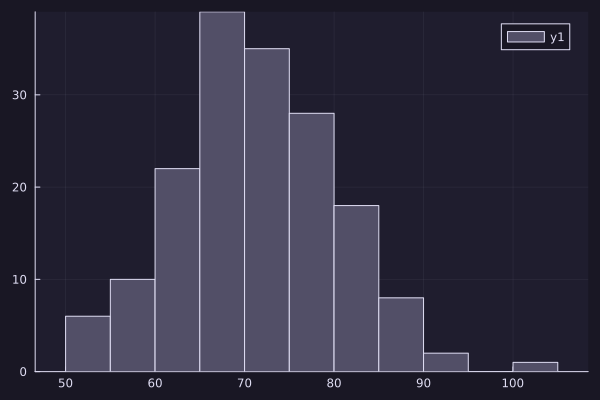

In [29]:
cliques_true = [Set{Int}() for _ in 1:k]
let
    for i in 1:t
        supi, _ = findnz(X_cpu[:,i])
        for j in supi
            push!(cliques_true[j], i)
        end
    end
end
histogram(length.(cliques_true))

In [30]:
g = let
    τ = 0.5
    g = SimpleGraph(t)
    dists = adapt(CPU(), ssds.D)

    for i in 1:t
        for j in i+1:t
            if dists[i,j] < τ
                add_edge!(g, i, j)
            end
        end
    end

    g
end

{3000, 415141} undirected simple Int64 graph

In [31]:
# cliques = let
#     thresh = minimum(length.(cliques_true))

#     lck = ReentrantLock();
#     cand_clqs = Set{Set{Int}}()

#     eglst = shuffle(collect(edges(g)))

#     @floop ThreadedEx() for (itr, e) in enumerate(eglst)
#         if length(cand_clqs) > k
#             break
#         end
#         u, v = src(e), dst(e)

#         # find common neighbors
#         cmn_neighs = common_neighbors(g, u, v)

        # if length(cmn_neighs) > thresh
        #     # add u and v to candidate clique
        #     push!(cmn_neighs, u, v)

        #     # get induced subgeraph of candidate clique
        #     gsub, vmap = induced_subgraph(g, cmn_neighs)

        #     # find maximum subclique
        #     loc_clq = maximum_clique(gsub)

        #     # map back to global node indecies
        #     glb_clq = Set([vmap[i] for i in loc_clq])

        #     if length(glb_clq) >= 3
        #         @lock lck push!(cand_clqs, glb_clq)
        #     end
        # end
#     end

#     println("$INF # cliques: ", length(cand_clqs))

#     # sort cliques by size
#     clqs = partialsort(collect(cand_clqs), 1:k; by=x->-length(x))

#     collect(clqs)
# end
# ;

In [32]:
function find_cliques_neighborhood(G::AbstractGraph, t::Int, s::Int, k::Int)
    # 1. Calculate the expected average clique size
    c = (t * s) / k
    
    # 2. Set a safe threshold for common neighbors.
    # Nodes in the same clique of size c will share c-2 neighbors.
    # We use a relaxed threshold (e.g., 60% of expected size) to account for natural variance 
    # in random clique sizes, while still being high enough to ignore spurious overlaps.
    threshold = max(1, floor(Int, c * 0.60 - 2))
    
    # We use a Set of sorted Vectors to automatically handle deduplication
    candidate_cliques = Set{Vector{Int}}()

    edglst = collect(edges(G))
    
    lck = ReentrantLock();

    @floop ThreadedEx() for e in edglst
        if length(candidate_cliques) > k
            break
        end
        
        u, v = src(e), dst(e)
        
        # Count how many neighbors u and v share
        common_neighs = collect(common_neighbors(G, u, v))
        
        if length(common_neighs) >= threshold
            # Form an initial candidate set containing u, v, and their shared neighbors
            candidate = push!(common_neighs, u, v)
            
            # Clean the candidate set to form a perfect clique
            clean_clique = refine_to_clique(G, candidate)
            
            if length(clean_clique) >= 3
                # if !(clean_clique ∈ candidate_cliques)
                    # println("$INF $(length(candidate_cliques)+1) $(length(clean_clique))")
                # end
                @lock lck push!(candidate_cliques, clean_clique)
            end
        end
    end
    
    # 3. Sort the unique cliques by size (descending) and return the top k
    unique_cliques = collect(candidate_cliques)
    sort!(unique_cliques, by=length, rev=true)
    
    return unique_cliques[1:min(k, length(unique_cliques))]
end

"""
    refine_to_clique(G::AbstractGraph, candidate::Vector{Int})

Greedily removes the lowest-degree nodes within the induced subgraph 
until the remaining nodes form a perfect, fully connected clique.
"""
function refine_to_clique(G::AbstractGraph, candidate::Vector{Int})
    # current_set = copy(candidate)
    current_set = candidate

    
    while true
        is_clique = true
        min_deg = length(current_set)
        node_to_remove = -1
        
        # Calculate the internal degree of each node within the candidate set
        for (i, u) in enumerate(current_set)
            deg_in_set = 0
            for v in current_set
                if u != v && has_edge(G, u, v)
                    deg_in_set += 1
                end
            end
            
            # If a node isn't connected to everyone else, it's not a perfect clique
            if deg_in_set < length(current_set) - 1
                is_clique = false
                if deg_in_set < min_deg
                    min_deg = deg_in_set
                    node_to_remove = i
                end
            end
        end
        
        # If every node is connected to every other node, we are done
        if is_clique
            break
        end
        
        # Remove the most "spurious" node and try again
        deleteat!(current_set, node_to_remove)
    end
    
    # Return sorted nodes so the Set deduplication works correctly
    return sort!(current_set)
end

cliques = find_cliques_neighborhood(g, t, s, k)
;

In [42]:
Dr_white = similar(D)
Y = W*D*X

# recover each column of dictionary
for i in 1:k
    M = Y[:, collect(cliques[i])]
    svdM = svd(M)
    Dr_white[:, i] .= svdM.U[:,1]
end

Dr = Winv * Dr_white
Dr_cpu = adapt(CPU(), Dr)

pir, pic, scale = align_dict_blocks(D_cpu, Dr_cpu)
Dr_cpu = apply_block_alignment(Dr_cpu, pir, pic, scale)
;

In [45]:
norm(D_cpu[:,1])

0.14342779339257694

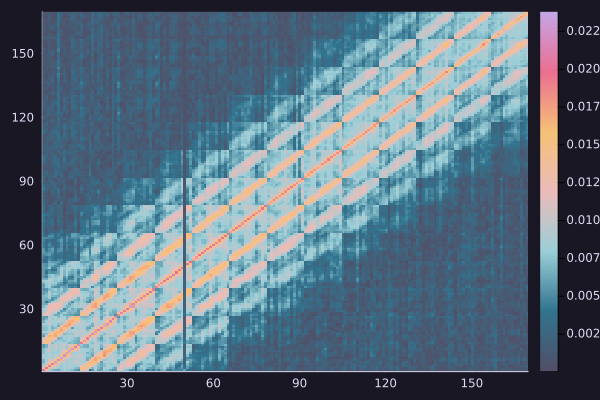

In [43]:
heatmap(abs.(D_cpu'*Dr_cpu))

In [44]:
println("$INF recovery fnorm error: $(norm(D_cpu - Dr_cpu)/norm(D_cpu))")
println("$INF minimum paired coherence: $(minimum(abs.(diag(D_cpu' * Dr_cpu))))")

[INF] recovery fnorm error: 0.21083980018553106
[INF] minimum paired coherence: 0.0017576612693383216
